<a href="https://colab.research.google.com/github/Sky-lark27/MARL-Framework/blob/main/Autonomous_RobotPathPlanning_DeepRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Autonomous Robot Path Planning using Deep Reinforcement Learning

This project demonstrates how an agent (robot) can learn to find the shortest path to a goal in a grid-based environment using **Deep Q-Learning** (DQN).

We use:
- Python
- OpenAI Gym (`FrozenLake-v1` environment)
- PyTorch (for the deep learning model)
- NumPy and Matplotlib (for calculations and visualization)

The goal is to teach the robot to:
✅ Navigate the environment  
⛔ Avoid obstacles  
🎯 Reach the goal using rewards and penalties






In [ ]:
#Install libraries
!pip install gym numpy matplotlib torch


In [ ]:
#Import dependencies

import gym
import torch
import torch.nn as nn #base class for all neural net mod. in PyTorch
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
#Deep Q-Network - This code defines a DQN using the PyTorch Library. This network will be used to approximate the Q-value function.
# The Q-value function is what the agent uses to determine the best action in a given state.

class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        # first fully connected (linear) layer of the network.
        # Takes state_size as input and has 64 neurons.
        self.fc1 = nn.Linear(state_size, 64)
        # second layer which takes 64 outputs from first layer as input and has 64 neurons.
        self.fc2 = nn.Linear(64, 64)
        # output layer, produces a vector of size action_size, where each element represents the Q-value for a possible action.
        self.fc3 = nn.Linear(64, action_size)

    # forward pass, input- state x, output- Q values for all possible actions
    def forward(self, x):
        # ReLU activation function for non-linearity into the model to learn more complex relationships.
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

This DQN takes the current state of the environment as input and outputs a set of Q-values, one for each possible action. The agent will then choose the action with the highest Q-value to maximize its expected future reward.

In [ ]:
#Init env
env = gym.make("FrozenLake-v1", is_slippery=False)  # Deterministic

state_size = env.observation_space.n #no. of poss. states= 0-15(16 for a 4x4 grid)
action_size = env.action_space.n #poss. actions- 4 (l,r,u,d)

def one_hot(state, size): #state to one-hot encoded vector (this vector= DQN input)
    vec = np.zeros(size)
    vec[state] = 1
    return vec

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
#Setting up the agent
q_net = DQN(state_size, action_size)
optimizer = optim.Adam(q_net.parameters(), lr=0.001) # Adam optimizer- to update wts. of NN
loss_fn = nn.MSELoss() # Mean Squared Error loss function

episodes = 5000 # Increased the number of episodes for training
gamma = 0.99 # discount factor - importance of future rewards (future rewards are almost as important as immediate rewards)
epsilon = 1.0 # epsilon-greedy strategy (starts with random exploration) controls the exploration-exploitation trade-off
epsilon_min = 0.1 # minimum value for epsilon
epsilon_decay = 0.995 # ensures that the agent explores less over time and exploits its learned knowledge more
replay_buffer = deque(maxlen=2000) # storing agent's experiences (state, action, reward, next_state, done)
batch_size = 64 # number of experiences to sample from the replay buffer for training
rewards_history = [] # list to store the total reward obtained in each episode

This code cell initializes the Deep Q-Network (DQN) agent with an Adam optimizer, MSE loss function, and parameters for the epsilon-greedy exploration strategy and experience replay buffer, along with variables to track rewards during training.


In [ ]:
pip install Gymnasium

This following code cell trains the Deep Q-Learning agent in the FrozenLake environment. It runs for a specified number of episodes, where in each episode, the agent interacts with the environment, collects experiences (state, action, reward, next state, done), stores them in a replay buffer, and uses these experiences to train the DQN model to predict the best actions. The training involves calculating target Q-values using the Bellman equation and updating the network weights to minimize the difference between predicted and target Q-values. The epsilon-greedy strategy is used to balance exploration and exploitation during training, with epsilon decaying over time.


In [ ]:
#Training the agent
for ep in range(episodes): # Loop for the specified number of episodes
    # Handle different return types of env.reset()
    state_info = env.reset()
    if isinstance(state_info, tuple):
        state = state_info[0]
    else:
        state = state_info

    # Ensure state is an integer, handle potential dictionary output
    if isinstance(state, dict):
         # Assuming the state integer is a value in the dictionary, try to extract it
         try:
             state = int(list(state.values())[0])
         except (ValueError, IndexError, TypeError):
             print(f"Warning: Could not extract integer state from env.reset() output: {state_info}. Skipping episode.")
             continue
    elif not isinstance(state, int):
         print(f"Warning: Unexpected state type from env.reset(): {type(state)}. Skipping episode.")
         continue

    state = one_hot(state, state_size) # Convert integer state to one-hot encoded vector
    total_reward = 0 # Initialize total reward for the episode
    episode_done = False # Flag to indicate if the episode is finished

    while not episode_done: # Loop until the episode is done
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = random.choice(range(action_size)) # Explore: choose a random action
        else:
            with torch.no_grad(): # Exploit: choose the action with the highest predicted Q-value
                q_vals = q_net(torch.FloatTensor(state))
                action = torch.argmax(q_vals).item()

        # Take the chosen action in the environment
        next_state_info = env.step(action)
        # Handle different return types of env.step() - unpack observation, reward, terminated, truncated
        if len(next_state_info) == 5:
            next_state, reward, terminated, truncated, _ = next_state_info # Unpack 5 values, discard the last one (info)
        elif len(next_state_info) == 4:
            next_state, reward, terminated, truncated = next_state_info # Unpack 4 values
        else:
             print(f"Warning: Unexpected output from env.step(): {next_state_info}. Breaking episode loop.")
             break

        # Determine if the episode is done based on termination or truncation
        step_done = terminated or truncated

        # Ensure next_state is an integer before one-hot encoding
        if isinstance(next_state, dict):
             try:
                 next_state = int(list(next_state.values())[0])
             except (ValueError, IndexError, TypeError):
                 print(f"Warning: Could not extract integer next_state from env.step() output: {next_state_info}. Breaking episode loop.")
                 break
        elif not isinstance(next_state, int):
             print(f"Warning: Unexpected next_state type from env.step(): {type(next_state)}. Breaking episode loop.")
             break


        next_state_encoded = one_hot(next_state, state_size) # Convert next state to one-hot encoding

        reward = 1 if next_state == 15 else reward  # Assign a reward of 1 for reaching the goal state (state 15)
        # Store the experience in the replay buffer
        replay_buffer.append((state, action, reward, next_state_encoded, step_done))
        state = next_state_encoded # Update the current state
        total_reward += reward # Add the reward to the total episode reward
        episode_done = step_done # Update the episode done flag

        # Train the DQN if the replay buffer has enough experiences
        if len(replay_buffer) >= batch_size:
            minibatch = random.sample(replay_buffer, batch_size) # Sample a random minibatch from the replay buffer

            # Explicitly separate components of the minibatch
            states = [exp[0] for exp in minibatch]
            actions = [exp[1] for exp in minibatch]
            rewards = [exp[2] for exp in minibatch]
            next_states = [exp[3] for exp in minibatch]
            dones_minibatch = [bool(exp[4]) for exp in minibatch]

            states = torch.FloatTensor(states)
            next_states = torch.FloatTensor(next_states)
            actions = torch.LongTensor(actions).unsqueeze(1)
            rewards = torch.FloatTensor(rewards)
            #FloatTensor (0.0 for False, 1.0 for True)
            dones = torch.FloatTensor([float(d) for d in dones_minibatch])

            q_vals = q_net(states).gather(1, actions).squeeze()
            # target Q-values using the Bellman equation
            with torch.no_grad():
                max_next_q_vals = q_net(next_states).max(1)[0]
            # (1 - done) ensures that if the episode is done, the future reward is not considered
            targets = rewards + gamma * max_next_q_vals * (1 - dones)

            # Loss calc and optimization- backprop
            loss = loss_fn(q_vals, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Decay epsilon to reduce exploration over time
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_history.append(total_reward)
    if (ep + 1) % 100 == 0:
        print(f"Episode {ep+1}, Reward: {total_reward}, Epsilon: {epsilon:.2f}")

Episode 100, Reward: 0.0, Epsilon: 0.61
Episode 200, Reward: 0.0, Epsilon: 0.37
Episode 300, Reward: 0.0, Epsilon: 0.22
Episode 400, Reward: 0.0, Epsilon: 0.13
Episode 500, Reward: 0.0, Epsilon: 0.10
Episode 600, Reward: 0.0, Epsilon: 0.10
Episode 700, Reward: 0.0, Epsilon: 0.10
Episode 800, Reward: 0.0, Epsilon: 0.10
Episode 900, Reward: 0.0, Epsilon: 0.10
Episode 1000, Reward: 0.0, Epsilon: 0.10
Episode 1100, Reward: 0.0, Epsilon: 0.10
Episode 1200, Reward: 0.0, Epsilon: 0.10
Episode 1300, Reward: 0.0, Epsilon: 0.10
Episode 1400, Reward: 0.0, Epsilon: 0.10
Episode 1500, Reward: 0.0, Epsilon: 0.10
Episode 1600, Reward: 0.0, Epsilon: 0.10
Episode 1700, Reward: 0.0, Epsilon: 0.10
Episode 1800, Reward: 0.0, Epsilon: 0.10
Episode 1900, Reward: 0.0, Epsilon: 0.10
Episode 2000, Reward: 0.0, Epsilon: 0.10
Episode 2100, Reward: 0.0, Epsilon: 0.10
Episode 2200, Reward: 0.0, Epsilon: 0.10
Episode 2300, Reward: 0.0, Epsilon: 0.10
Episode 2400, Reward: 0.0, Epsilon: 0.10
Episode 2500, Reward: 0.0

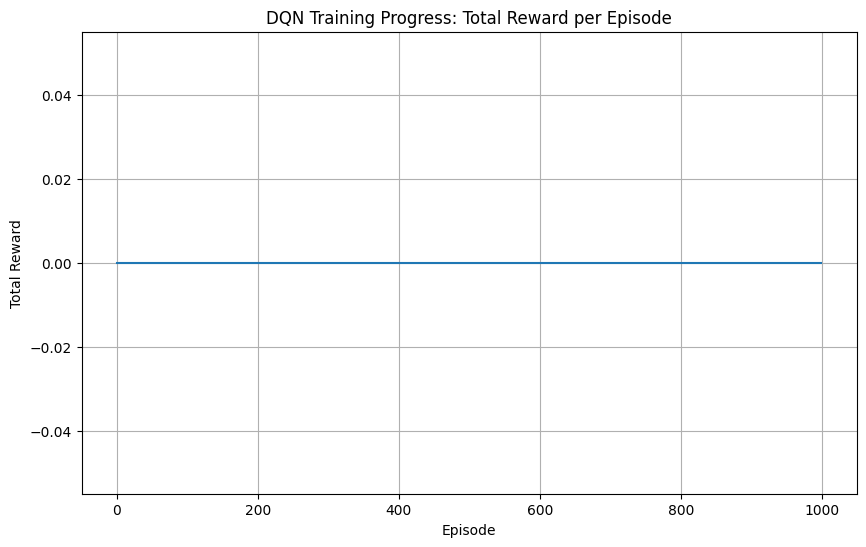

In [ ]:
# Visualize training progress
plt.figure(figsize=(10, 6))
plt.plot(rewards_history)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DQN Training Progress: Total Reward per Episode')
plt.grid(True)
plt.show()